# MNIST CNN Baseline

This notebook establishes the single-process PyTorch CNN baseline that will be used as the reference for subsequent distributed training experiments.

In [9]:
import time
import random
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

In [23]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", device)
print("CPU threads:", torch.get_num_threads())

PyTorch: 2.14.1+cu130
Torchvision: 0.29.1+cu130
Device: cpu
CPU threads: 8


## Dataset

MNIST consists of 28×28 grayscale handwritten-digit images belonging to 10 classes (digits 0–9).

For the baseline, the dataset is loaded directly through `torchvision` rather than HDFS/Spark. 

HDFS/Spark will be introduced in later experiments.

In [6]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100.0%
100.0%
100.0%
100.0%

Training samples: 60000
Test samples: 10000


In [7]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Image range:", image.min().item(), "to", image.max().item())
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Image dtype: torch.float32
Image range: 0.0 to 1.0
Label: 5


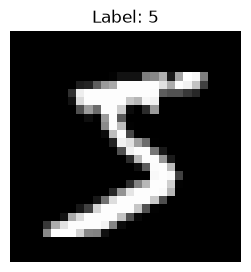

In [8]:
plt.figure(figsize=(3, 3))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off");

## DataLoaders

The training and test datasets are divided into mini-batches for model training and evaluation. A batch size of 128 is used as the
initial experimental setting and will be kept constant when comparing the baseline and distributed configurations.

In [12]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True   # at the beginning of each epoch, the training samples are presented in a different order
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Batch size:", batch_size)
print("Training batches:", len(train_loader))
print("Test batches:", len(test_loader))

Batch size: 128
Training batches: 469
Test batches: 79


## CNN Architecture

A small convolutional neural network (CNN) is used as the baseline classifier for MNIST. The same architecture and training
hyperparameters will be retained for subsequent experiments where possible, so that changes in results can be attributed to the
computational configuration rather than to a different model.

In [14]:
import torch.nn as nn
import torch.nn.functional as F

class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3
        )

        self.pool = nn.MaxPool2d(kernel_size=2)

        self.fc1 = nn.Linear(32 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, start_dim=1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [24]:
model = MNISTCNN()
print(model)

MNISTCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [16]:
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 108618


In [18]:
images, labels = next(iter(train_loader))
outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([128, 1, 28, 28])
Output shape: torch.Size([128, 10])


## Loss Function and Optimizer

Cross-entropy loss is used for the multi-class classification task.
The Adam optimizer is used to update the model parameters during training.

In [37]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

learning_rate = 0.001

In [29]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        optimizer.zero_grad()   # clear gradients from the previous batch

        outputs = model(images)   # perform the forward pass
        loss = criterion(outputs, labels)   # calculate the classification loss
        loss.backward()   # calculate gradients
        optimizer.step()   # update model parameters

        # CrossEntropyLoss() by default returns the average loss for the batch
        # we want the running_loss to represent the sum of the individual sample losses
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [30]:
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # we're telling PyTorch that this is evaluation rather than training, and that we don't need to calculate gradients
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## Training

The baseline CNN is trained for 5 epochs using the Adam optimizer with a learning rate of 0.001 and a batch size of 128.

In [32]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
    "epoch_time": []
}

epochs = 5

for epoch in range(epochs):
    start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer)

    test_loss, test_accuracy = evaluate(model, test_loader, criterion)

    epoch_time = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_accuracy)
    history["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:.4f} | "
        f"Test loss: {test_loss:.4f} | "
        f"Test acc: {test_accuracy:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

Epoch 1/5 | Train loss: 0.0822 | Train acc: 0.9754 | Test loss: 0.0558 | Test acc: 0.9828 | Time: 14.94s
Epoch 2/5 | Train loss: 0.0576 | Train acc: 0.9821 | Test loss: 0.0529 | Test acc: 0.9836 | Time: 14.60s
Epoch 3/5 | Train loss: 0.0455 | Train acc: 0.9861 | Test loss: 0.0396 | Test acc: 0.9868 | Time: 14.44s
Epoch 4/5 | Train loss: 0.0370 | Train acc: 0.9886 | Test loss: 0.0413 | Test acc: 0.9873 | Time: 14.74s
Epoch 5/5 | Train loss: 0.0305 | Train acc: 0.9907 | Test loss: 0.0343 | Test acc: 0.9874 | Time: 16.17s


In [33]:
# overall training time
total_training_time = sum(history["epoch_time"])

print(f"Total training time: {total_training_time:.2f} seconds")
print(f"Average epoch time: {np.mean(history['epoch_time']):.2f} seconds")
print(f"Final test accuracy: {history['test_accuracy'][-1]:.4f}")

Total training time: 74.89 seconds
Average epoch time: 14.98 seconds
Final test accuracy: 0.9874


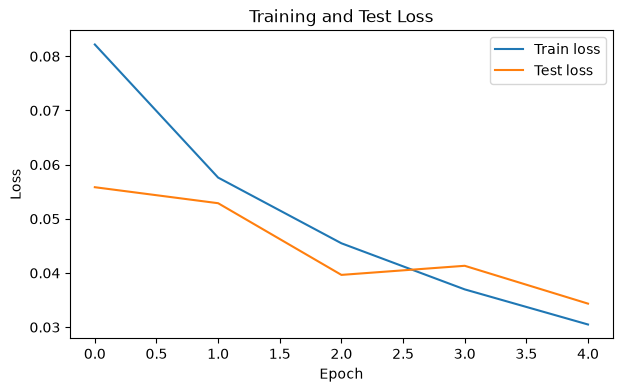

In [34]:
# plot the learning curves
plt.figure(figsize=(7, 4))

plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["test_loss"], label="Test loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()

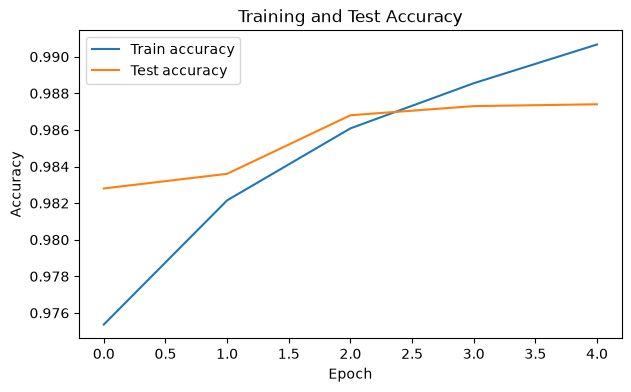

In [35]:
plt.figure(figsize=(7, 4))

plt.plot(history["train_accuracy"], label="Train accuracy")
plt.plot(history["test_accuracy"], label="Test accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.show()

In [38]:
# save the baseline configuration/results in a compact table so that we don't have to reconstruct them later
baseline_results = {
    "model": "MNISTCNN",
    "parameters": total_params,
    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "optimizer": "Adam",
    "train_accuracy": history["train_accuracy"][-1],
    "test_accuracy": history["test_accuracy"][-1],
    "total_time_s": total_training_time,
    "average_epoch_time_s": np.mean(history["epoch_time"]),
    "cpu_threads": torch.get_num_threads()
}

baseline_results

{'model': 'MNISTCNN',
 'parameters': 108618,
 'epochs': 5,
 'batch_size': 128,
 'learning_rate': 0.001,
 'optimizer': 'Adam',
 'train_accuracy': 0.9906666666666667,
 'test_accuracy': 0.9874,
 'total_time_s': 74.88735818862915,
 'average_epoch_time_s': np.float64(14.97747163772583),
 'cpu_threads': 8}

### Baseline result

The single-process CPU CNN achieved 98.74% test accuracy after 5 epochs, with a total training time of 74.89 seconds and an average epoch time of 14.98 seconds. This configuration is retained as the baseline for subsequent experiments.

## Resources:

- https://www.geeksforgeeks.org/deep-learning/building-a-convolutional-neural-network-using-pytorch/
- 